# NB0 — Smoke test & shared config (no training)

**VLM Semantic-Bias XAI on a Genesis / Unitree Go2 quadruped — minimum-viable demo.**

This notebook is the empirical-verification stage. It installs everything, writes the shared modules
(`go2_env.py`, `qre_utils.py`, `config.py`) to Google Drive, and **confirms every uncertain API**
before any training happens:

1. A100 + CUDA present
2. Headless EGL/Xvfb rendering works
3. Genesis renders the Go2 in the flat arena **and** the two-goal bias arena (red vs. blue)
4. The camera returns a **depth** buffer; intrinsics/extrinsics build correctly (needed for NB4 saliency)
5. The **high-quality render profile** works: black floor + white grid, lights, shadows (§5.8)
6. **Qwen2.5-VL-3B** loads in bf16, obeys the JSON output contract, parses to a **single-token `turn`**, and returns a reshapeable attention map over the image patches

> ⚠️ Runtime → Change runtime type → **A100 GPU**. This is a multi-session program; outputs go to Drive so later notebooks resume from here.

> Authoring note: this scaffold is grounded in the working `example_quadruped.ipynb` (Genesis 0.4.6) and the Qwen2.5-VL model card, but the cells marked **VERIFY** exercise APIs that vary across library versions. Run them and let the asserts catch problems in seconds rather than mid-training.

In [ ]:
# 1. Verify the A100 GPU
!nvidia-smi
import torch
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))
assert torch.cuda.is_available(), "No CUDA GPU — set Runtime → A100 GPU."

Tue Jun  2 05:07:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# 2. Mount Google Drive + create the project layout
from google.colab import drive
import os, pathlib
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = '/content/drive/MyDrive/quadruped_vlm_xai'
SUBDIRS = ['config', 'logs', 'videos', 'trials', 'saliency']
for d in [DRIVE_ROOT] + [f'{DRIVE_ROOT}/{s}' for s in SUBDIRS]:
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)
print('Drive root:', DRIVE_ROOT)
print('Layout:', os.listdir(DRIVE_ROOT))

Mounted at /content/drive
Drive root: /content/drive/MyDrive/quadruped_vlm_xai
Layout: ['config', 'logs', 'videos', 'trials', 'saliency']


In [ ]:
# 3. System-level dependencies (headless OpenGL + ffmpeg). ~1-2 min.
%%bash
set -e
apt-get update -qq
apt-get install -y -qq \
    xvfb x11-utils libgl1 libglu1-mesa libegl1 libopengl0 \
    libglfw3 libglew2.2 libosmesa6 freeglut3-dev ffmpeg > /dev/null
echo "System deps installed."

System deps installed.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
# 4. Python dependencies. Do NOT reinstall torch (use Colab's CUDA build).
%%capture
!pip install -q --upgrade pip
# Locomotion stack (exact pins from the reference notebook)
!pip install -q genesis-world 'rsl-rl-lib==2.2.4' tensorboard pyvirtualdisplay mediapy 'imageio[ffmpeg]'
# VLM + XAI stack
!pip install -q -U transformers accelerate qwen-vl-utils open3d scipy scikit-image opencv-python matplotlib

In [ ]:
# Report versions
import importlib.metadata as M
for pkg in ['genesis-world','rsl-rl-lib','torch','transformers','open3d']:
    try: print(f'{pkg:<15} {M.version(pkg)}')
    except M.PackageNotFoundError: print(f'{pkg:<15} NOT INSTALLED')

genesis-world   1.0.0
rsl-rl-lib      2.2.4
torch           2.11.0+cu128
transformers    5.9.0
open3d          0.19.0


In [ ]:
# 5. Configure headless rendering. MUST run before the first `import genesis`.
import os
os.environ['PYOPENGL_PLATFORM'] = 'egl'
os.environ['MUJOCO_GL'] = 'egl'
os.environ['EGL_PLATFORM'] = 'surfaceless'
os.environ['NVIDIA_DRIVER_CAPABILITIES'] = 'compute,graphics,utility'
os.environ['NVIDIA_VISIBLE_DEVICES'] = 'all'
from pyvirtualdisplay import Display
_display = Display(visible=0, size=(1280, 720)); _display.start()
os.environ['DISPLAY'] = f':{_display.display}'
print('Xvfb DISPLAY =', os.environ['DISPLAY'], '| PYOPENGL_PLATFORM =', os.environ['PYOPENGL_PLATFORM'])

Xvfb DISPLAY = :0 | PYOPENGL_PLATFORM = egl


## 6. Write `go2_env.py` (flat Go2 environment)

This is the official Genesis flat-plane Go2 env from the reference notebook — a gym-style parallel
interface (`reset()`/`step(actions)`), 12 actions, 45-dim observation, PD-controlled joints at 50 Hz.
NB1 trains a PPO `locomote` policy on it; NB2 drives it with the VLM.

In [ ]:
%%writefile /content/go2_env.py
import math
import torch
import genesis as gs
from genesis.utils.geom import quat_to_xyz, transform_by_quat, inv_quat, transform_quat_by_quat

def gs_rand_float(lower, upper, shape, device):
    return (upper - lower) * torch.rand(size=shape, device=device) + lower

class Go2Env:
    def __init__(self, num_envs, env_cfg, obs_cfg, reward_cfg, command_cfg,
                 show_viewer=False, attach_camera=False, camera_res=(960, 640),
                 camera_pos=(2.5, 1.0, 1.2), camera_lookat=(0.0, 0.0, 0.3), camera_fov=40,
                 env_spacing=None, rendered_envs_idx=None, hiq=False, grid_texture=None,
                 extra_objects=None):
        self.num_envs = num_envs
        self.num_obs = obs_cfg["num_obs"]
        self.num_privileged_obs = None
        self.num_actions = env_cfg["num_actions"]
        self.num_commands = command_cfg["num_commands"]
        self.device = gs.device

        self.simulate_action_latency = True
        self.dt = 0.02  # 50 Hz control
        self.max_episode_length = math.ceil(env_cfg["episode_length_s"] / self.dt)

        self.env_cfg = env_cfg
        self.obs_cfg = obs_cfg
        self.reward_cfg = reward_cfg
        self.command_cfg = command_cfg
        self.obs_scales = obs_cfg["obs_scales"]
        self.reward_scales = reward_cfg["reward_scales"]

        if rendered_envs_idx is None:
            rendered_envs_idx = [0]

        # ---- scene (optionally high-quality: lights + shadows, plan §5.8)
        if hiq:
            import sys; sys.path.insert(0, '/content')
            import qre_utils as _U
            self.scene, _ = _U.build_hiq_scene(gs, dt=self.dt, rendered_envs_idx=rendered_envs_idx)
        else:
            self.scene = gs.Scene(
                sim_options=gs.options.SimOptions(dt=self.dt, substeps=2),
                viewer_options=gs.options.ViewerOptions(
                    max_FPS=int(0.5 / self.dt),
                    camera_pos=(2.0, 0.0, 2.5), camera_lookat=(0.0, 0.0, 0.5), camera_fov=40),
                vis_options=gs.options.VisOptions(rendered_envs_idx=rendered_envs_idx),
                rigid_options=gs.options.RigidOptions(
                    dt=self.dt, constraint_solver=gs.constraint_solver.Newton,
                    enable_collision=True, enable_joint_limit=True),
                show_viewer=show_viewer,
            )

        # ---- ground (grid floor when hiq) + optional goal objects + robot
        if hiq and grid_texture:
            import sys; sys.path.insert(0, '/content')
            import qre_utils as _U
            _U.add_ground(gs, self.scene, grid_texture)
        else:
            self.scene.add_entity(gs.morphs.URDF(file="urdf/plane/plane.urdf", fixed=True))
        if extra_objects:
            import sys; sys.path.insert(0, '/content')
            import qre_utils as _U
            for ob in extra_objects:
                _U.add_colored_box(gs, self.scene, ob['pos'], ob['size'], ob['color'])
        self.base_init_pos = torch.tensor(env_cfg["base_init_pos"], device=gs.device)
        self.base_init_quat = torch.tensor(env_cfg["base_init_quat"], device=gs.device)
        self.inv_base_init_quat = inv_quat(self.base_init_quat)
        self.robot = self.scene.add_entity(gs.morphs.URDF(
            file="urdf/go2/urdf/go2.urdf",
            pos=self.base_init_pos.cpu().numpy(),
            quat=self.base_init_quat.cpu().numpy()))

        # ---- optional recording camera
        self.camera = None
        if attach_camera:
            self.camera = self.scene.add_camera(
                res=camera_res, pos=camera_pos, lookat=camera_lookat, fov=camera_fov, GUI=False)

        # ---- build
        build_kwargs = {"n_envs": num_envs}
        if env_spacing is not None:
            build_kwargs["env_spacing"] = env_spacing
        self.scene.build(**build_kwargs)

        self.motors_dof_idx = [self.robot.get_joint(n).dof_start for n in env_cfg["joint_names"]]
        self.robot.set_dofs_kp([env_cfg["kp"]] * self.num_actions, self.motors_dof_idx)
        self.robot.set_dofs_kv([env_cfg["kd"]] * self.num_actions, self.motors_dof_idx)

        self.reward_functions, self.episode_sums = {}, {}
        for name in self.reward_scales.keys():
            self.reward_scales[name] *= self.dt
            self.reward_functions[name] = getattr(self, "_reward_" + name)
            self.episode_sums[name] = torch.zeros((self.num_envs,), device=gs.device, dtype=gs.tc_float)

        self.base_lin_vel = torch.zeros((self.num_envs, 3), device=gs.device, dtype=gs.tc_float)
        self.base_ang_vel = torch.zeros((self.num_envs, 3), device=gs.device, dtype=gs.tc_float)
        self.projected_gravity = torch.zeros((self.num_envs, 3), device=gs.device, dtype=gs.tc_float)
        self.global_gravity = torch.tensor([0.0, 0.0, -1.0], device=gs.device, dtype=gs.tc_float).repeat(self.num_envs, 1)
        self.obs_buf = torch.zeros((self.num_envs, self.num_obs), device=gs.device, dtype=gs.tc_float)
        self.rew_buf = torch.zeros((self.num_envs,), device=gs.device, dtype=gs.tc_float)
        self.reset_buf = torch.ones((self.num_envs,), device=gs.device, dtype=gs.tc_int)
        self.episode_length_buf = torch.zeros((self.num_envs,), device=gs.device, dtype=gs.tc_int)
        self.commands = torch.zeros((self.num_envs, self.num_commands), device=gs.device, dtype=gs.tc_float)
        self.commands_scale = torch.tensor(
            [self.obs_scales["lin_vel"], self.obs_scales["lin_vel"], self.obs_scales["ang_vel"]],
            device=gs.device, dtype=gs.tc_float)
        self.actions = torch.zeros((self.num_envs, self.num_actions), device=gs.device, dtype=gs.tc_float)
        self.last_actions = torch.zeros_like(self.actions)
        self.dof_pos = torch.zeros_like(self.actions)
        self.dof_vel = torch.zeros_like(self.actions)
        self.last_dof_vel = torch.zeros_like(self.actions)
        self.base_pos = torch.zeros((self.num_envs, 3), device=gs.device, dtype=gs.tc_float)
        self.base_quat = torch.zeros((self.num_envs, 4), device=gs.device, dtype=gs.tc_float)
        self.default_dof_pos = torch.tensor(
            [env_cfg["default_joint_angles"][n] for n in env_cfg["joint_names"]],
            device=gs.device, dtype=gs.tc_float)
        self.extras = {"observations": {}}

    def _resample_commands(self, envs_idx):
        self.commands[envs_idx, 0] = gs_rand_float(*self.command_cfg["lin_vel_x_range"], (len(envs_idx),), gs.device)
        self.commands[envs_idx, 1] = gs_rand_float(*self.command_cfg["lin_vel_y_range"], (len(envs_idx),), gs.device)
        self.commands[envs_idx, 2] = gs_rand_float(*self.command_cfg["ang_vel_range"], (len(envs_idx),), gs.device)

    def step(self, actions):
        self.actions = torch.clip(actions, -self.env_cfg["clip_actions"], self.env_cfg["clip_actions"])
        exec_actions = self.last_actions if self.simulate_action_latency else self.actions
        target_dof_pos = exec_actions * self.env_cfg["action_scale"] + self.default_dof_pos
        self.robot.control_dofs_position(target_dof_pos, self.motors_dof_idx)
        self.scene.step()

        self.episode_length_buf += 1
        self.base_pos[:] = self.robot.get_pos()
        self.base_quat[:] = self.robot.get_quat()
        self.base_euler = quat_to_xyz(
            transform_quat_by_quat(torch.ones_like(self.base_quat) * self.inv_base_init_quat, self.base_quat),
            rpy=True, degrees=True)
        inv_base_quat = inv_quat(self.base_quat)
        self.base_lin_vel[:] = transform_by_quat(self.robot.get_vel(), inv_base_quat)
        self.base_ang_vel[:] = transform_by_quat(self.robot.get_ang(), inv_base_quat)
        self.projected_gravity = transform_by_quat(self.global_gravity, inv_base_quat)
        self.dof_pos[:] = self.robot.get_dofs_position(self.motors_dof_idx)
        self.dof_vel[:] = self.robot.get_dofs_velocity(self.motors_dof_idx)

        envs_idx = ((self.episode_length_buf % int(self.env_cfg["resampling_time_s"] / self.dt) == 0)
                    .nonzero(as_tuple=False).reshape((-1,)))
        self._resample_commands(envs_idx)

        self.reset_buf = self.episode_length_buf > self.max_episode_length
        self.reset_buf |= torch.abs(self.base_euler[:, 1]) > self.env_cfg["termination_if_pitch_greater_than"]
        self.reset_buf |= torch.abs(self.base_euler[:, 0]) > self.env_cfg["termination_if_roll_greater_than"]

        time_out_idx = (self.episode_length_buf > self.max_episode_length).nonzero(as_tuple=False).reshape((-1,))
        self.extras["time_outs"] = torch.zeros_like(self.reset_buf, device=gs.device, dtype=gs.tc_float)
        self.extras["time_outs"][time_out_idx] = 1.0
        self.reset_idx(self.reset_buf.nonzero(as_tuple=False).reshape((-1,)))

        self.rew_buf[:] = 0.0
        for name, fn in self.reward_functions.items():
            rew = fn() * self.reward_scales[name]
            self.rew_buf += rew
            self.episode_sums[name] += rew

        self.obs_buf = torch.cat([
            self.base_ang_vel * self.obs_scales["ang_vel"],
            self.projected_gravity,
            self.commands * self.commands_scale,
            (self.dof_pos - self.default_dof_pos) * self.obs_scales["dof_pos"],
            self.dof_vel * self.obs_scales["dof_vel"],
            self.actions,
        ], dim=-1)

        self.last_actions[:] = self.actions[:]
        self.last_dof_vel[:] = self.dof_vel[:]
        self.extras["observations"]["critic"] = self.obs_buf
        return self.obs_buf, self.rew_buf, self.reset_buf, self.extras

    def get_observations(self):
        self.extras["observations"]["critic"] = self.obs_buf
        return self.obs_buf, self.extras

    def get_privileged_observations(self):
        return None

    def reset_idx(self, envs_idx):
        if len(envs_idx) == 0:
            return
        self.dof_pos[envs_idx] = self.default_dof_pos
        self.dof_vel[envs_idx] = 0.0
        self.robot.set_dofs_position(position=self.dof_pos[envs_idx], dofs_idx_local=self.motors_dof_idx,
                                     zero_velocity=True, envs_idx=envs_idx)
        self.base_pos[envs_idx] = self.base_init_pos
        self.base_quat[envs_idx] = self.base_init_quat.reshape(1, -1)
        self.robot.set_pos(self.base_pos[envs_idx], zero_velocity=False, envs_idx=envs_idx)
        self.robot.set_quat(self.base_quat[envs_idx], zero_velocity=False, envs_idx=envs_idx)
        self.base_lin_vel[envs_idx] = 0
        self.base_ang_vel[envs_idx] = 0
        self.robot.zero_all_dofs_velocity(envs_idx)
        self.last_actions[envs_idx] = 0.0
        self.last_dof_vel[envs_idx] = 0.0
        self.episode_length_buf[envs_idx] = 0
        self.reset_buf[envs_idx] = True
        self.extras["episode"] = {}
        for k in self.episode_sums.keys():
            self.extras["episode"]["rew_" + k] = (
                torch.mean(self.episode_sums[k][envs_idx]).item() / self.env_cfg["episode_length_s"])
            self.episode_sums[k][envs_idx] = 0.0
        self._resample_commands(envs_idx)

    def reset(self):
        self.reset_buf[:] = True
        self.reset_idx(torch.arange(self.num_envs, device=gs.device))
        return self.obs_buf, None

    # ---- rewards
    def _reward_tracking_lin_vel(self):
        err = torch.sum(torch.square(self.commands[:, :2] - self.base_lin_vel[:, :2]), dim=1)
        return torch.exp(-err / self.reward_cfg["tracking_sigma"])

    def _reward_tracking_ang_vel(self):
        err = torch.square(self.commands[:, 2] - self.base_ang_vel[:, 2])
        return torch.exp(-err / self.reward_cfg["tracking_sigma"])

    def _reward_lin_vel_z(self):
        return torch.square(self.base_lin_vel[:, 2])

    def _reward_action_rate(self):
        return torch.sum(torch.square(self.last_actions - self.actions), dim=1)

    def _reward_similar_to_default(self):
        return torch.sum(torch.abs(self.dof_pos - self.default_dof_pos), dim=1)

    def _reward_base_height(self):
        return torch.square(self.base_pos[:, 2] - self.reward_cfg["base_height_target"])

Writing /content/go2_env.py


## 7. Write `qre_utils.py` (shared render + VLM + saliency utilities)

Everything reused across notebooks lives here: the **high-quality render profile** (black floor +
white grid, lights, shadows), the **sanity gate**, camera **intrinsics/extrinsics + unprojection**
(for NB4), the **two-goal arena builder** (red vs. blue), and the **Qwen2.5-VL** load / JSON-contract /
robust-parser / **single-token `turn` attention** extractor.

Calls that vary across Genesis/Transformers versions are wrapped defensively and verified below.

In [ ]:
%%writefile /content/qre_utils.py
import os, json, re, math
import numpy as np

# ----------------------------------------------------------------------------------
# Bucketed action maps (LOCKED, see plan §5.7). Single integer token => clean saliency anchor.
TURN_TO_WZ  = {0: -1.0, 1: -0.5, 2: 0.0, 3: 0.5, 4: 1.0}   # 0=hard-right ... 4=hard-left
SPEED_TO_VX = {0: 0.0, 1: 0.6, 2: 1.2}                       # 0=stop, 1=walk, 2=fast
VY_FIXED    = 0.0

def bucket_to_command(turn, speed):
    """Map VLM buckets to a clamped (v_x, v_y, w_z) command."""
    turn  = int(max(0, min(4, turn)))
    speed = int(max(0, min(2, speed)))
    return float(SPEED_TO_VX[speed]), float(VY_FIXED), float(TURN_TO_WZ[turn])

# ----------------------------------------------------------------------------------
# High-quality render profile (plan §5.8)
def make_grid_texture(path, size_px=1024, n_cells=16, line_px=4):
    """Black floor with thin white grid lines. Saved as PNG, applied as a diffuse texture."""
    import imageio.v2 as imageio
    img = np.zeros((size_px, size_px, 3), dtype=np.uint8)  # black
    step = size_px // n_cells
    for i in range(0, size_px + 1, step):
        lo = max(0, i - line_px // 2); hi = min(size_px, i + line_px // 2 + 1)
        img[lo:hi, :, :] = 255
        img[:, lo:hi, :] = 255
    imageio.imwrite(path, img)
    return path

def build_hiq_scene(gs, dt=0.02, rendered_envs_idx=(0,)):
    """Construct a gs.Scene with lights + shadows when supported, else a safe fallback.
    Returns (scene, used_hiq: bool). VERIFY in NB0 — VisOptions fields vary by version."""
    rigid = gs.options.RigidOptions(dt=dt, constraint_solver=gs.constraint_solver.Newton,
                                    enable_collision=True, enable_joint_limit=True)
    sim = gs.options.SimOptions(dt=dt, substeps=2)
    # Try a rich VisOptions; fall back progressively.
    vis_attempts = [
        dict(rendered_envs_idx=list(rendered_envs_idx), shadow=True,
             ambient_light=(0.25, 0.25, 0.25),
             lights=[{"type": "directional", "dir": (-0.5, -0.6, -1.0),
                      "color": (1.0, 1.0, 1.0), "intensity": 6.0}]),
        dict(rendered_envs_idx=list(rendered_envs_idx), shadow=True),
        dict(rendered_envs_idx=list(rendered_envs_idx)),
    ]
    for i, kw in enumerate(vis_attempts):
        try:
            scene = gs.Scene(sim_options=sim, vis_options=gs.options.VisOptions(**kw),
                             rigid_options=rigid, show_viewer=False)
            return scene, (i == 0)
        except TypeError:
            continue
    scene = gs.Scene(sim_options=sim, rigid_options=rigid, show_viewer=False)
    return scene, False

def add_ground(gs, scene, grid_texture_path=None):
    """Add the floor. Try a grid-textured surface, else a plain dark plane. VERIFY in NB0."""
    morph = gs.morphs.URDF(file="urdf/plane/plane.urdf", fixed=True)
    if grid_texture_path and os.path.exists(grid_texture_path):
        for surf in (
            lambda: gs.surfaces.Default(diffuse_texture=gs.textures.ImageTexture(image_path=grid_texture_path)),
            lambda: gs.surfaces.Rough(diffuse_texture=gs.textures.ImageTexture(image_path=grid_texture_path)),
        ):
            try:
                return scene.add_entity(morph, surface=surf())
            except Exception:
                continue
    try:
        return scene.add_entity(morph, surface=gs.surfaces.Default(color=(0.05, 0.05, 0.05)))
    except Exception:
        return scene.add_entity(morph)

def add_colored_box(gs, scene, pos, size, color):
    """Add a fixed colored rectangle (a candidate goal object). VERIFY surface API in NB0."""
    morph = gs.morphs.Box(pos=tuple(pos), size=tuple(size), fixed=True)
    for surf in (lambda: gs.surfaces.Default(color=tuple(color)),
                 lambda: gs.surfaces.Rough(color=tuple(color))):
        try:
            return scene.add_entity(morph, surface=surf())
        except Exception:
            continue
    return scene.add_entity(morph)

# ----------------------------------------------------------------------------------
# Camera geometry for saliency (plan §5.4)
def camera_intrinsics(res, fov_deg):
    """Pinhole K from horizontal-ish fov + resolution. Genesis fov is vertical; adjust if NB0 shows otherwise."""
    w, h = res
    fov = math.radians(fov_deg)
    fy = (h / 2) / math.tan(fov / 2)
    fx = fy  # square pixels
    cx, cy = w / 2.0, h / 2.0
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)
    return K

def look_at_extrinsics(cam_pos, lookat, up=(0, 0, 1)):
    """World->camera transform T_cw (4x4) and camera->world T_wc. OpenCV convention (+z forward)."""
    cam_pos = np.asarray(cam_pos, float); lookat = np.asarray(lookat, float); up = np.asarray(up, float)
    f = lookat - cam_pos; f /= (np.linalg.norm(f) + 1e-9)
    r = np.cross(f, up); r /= (np.linalg.norm(r) + 1e-9)
    u = np.cross(r, f)
    R_wc = np.stack([r, -u, f], axis=1)         # camera axes in world (x right, y down, z forward)
    T_wc = np.eye(4); T_wc[:3, :3] = R_wc; T_wc[:3, 3] = cam_pos
    T_cw = np.linalg.inv(T_wc)
    return T_cw, T_wc

def unproject(u, v, depth, K, T_wc):
    """Pixel (u,v) + metric depth -> world XYZ. depth is along the camera +z axis."""
    x = (u - K[0, 2]) / K[0, 0] * depth
    y = (v - K[1, 2]) / K[1, 1] * depth
    p_cam = np.array([x, y, depth, 1.0])
    return (T_wc @ p_cam)[:3]

# ----------------------------------------------------------------------------------
# Render-and-assert sanity gate (plan §5.2)
def render_camera(camera, want_depth=True):
    """Call camera.render and return (rgb_uint8, depth_or_None). VERIFY signature in NB0.
    Genesis camera.render typically returns (rgb, depth, seg, normal) for requested buffers."""
    out = None
    for kwargs in ({"rgb": True, "depth": want_depth}, {}):
        try:
            out = camera.render(**kwargs); break
        except TypeError:
            continue
    if not isinstance(out, (tuple, list)):
        rgb = np.asarray(out); return rgb, None
    rgb = np.asarray(out[0])
    depth = None
    if want_depth and len(out) > 1 and out[1] is not None:
        depth = np.asarray(out[1])
    return rgb, depth

def sanity_gate(scene, robot, camera, save_png, n_steps=8, bound=5.0, z_max=2.0):
    """Step with tiny random actions, assert physical sanity + a usable RGB(+depth) frame."""
    import torch, imageio.v2 as imageio
    for _ in range(n_steps):
        scene.step()
    pos = np.asarray(robot.get_pos().cpu()) if hasattr(robot.get_pos(), "cpu") else np.asarray(robot.get_pos())
    pos = pos.reshape(-1, 3)[0]
    assert np.all(np.isfinite(pos)), f"NaN/Inf base pos {pos}"
    assert abs(pos[0]) < bound and abs(pos[1]) < bound, f"Robot launched away: {pos}"
    assert 0 < pos[2] < z_max, f"Bad base height: {pos[2]}"
    rgb, depth = render_camera(camera, want_depth=True)
    assert rgb is not None and rgb.size > 0 and rgb.std() > 1.0, "Degenerate RGB frame"
    imageio.imwrite(save_png, rgb[..., :3].astype(np.uint8))
    depth_ok = depth is not None and np.isfinite(depth).any() and float(np.nanstd(depth)) > 1e-4
    return dict(base_pos=pos.tolist(), rgb_shape=tuple(rgb.shape),
                depth_present=depth is not None, depth_nondegenerate=bool(depth_ok),
                png=save_png)

# ----------------------------------------------------------------------------------
# Two-goal bias arena (plan §7). Red vs. blue, luminance-matched.
# sRGB relative luminance L = 0.2126 R + 0.7152 G + 0.0722 B. We pick a red and a blue with equal L.
def luminance(c):
    r, g, b = c
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

# Equal-luminance red/blue (L ~= 0.21): pure-ish red, brightened blue.
COLOR_RED  = (0.99, 0.05, 0.05)
COLOR_BLUE = (0.05, 0.05, 0.99)
# blue luminance is lower; scale blue up to match red's luminance via an added neutral component
def luminance_match(ref, other):
    """Return `other` blended toward white to match ref luminance (keeps hue dominant)."""
    Lref, Loth = luminance(ref), luminance(other)
    if Loth >= Lref:
        return other
    # add gray g to all channels so luminance rises to Lref
    g = (Lref - Loth)
    return tuple(min(1.0, c + g) for c in other)

def goal_positions(distance=3.0, lateral=1.2, left_color=None, right_color=None):
    """Two rectangles, equal forward distance, symmetric left/right. Robot starts at origin facing +x."""
    left  = dict(pos=(distance, +lateral, 0.25), size=(0.4, 0.4, 0.5), color=left_color,  side="left")
    right = dict(pos=(distance, -lateral, 0.25), size=(0.4, 0.4, 0.5), color=right_color, side="right")
    return left, right

# ----------------------------------------------------------------------------------
# Qwen2.5-VL: load, prompt contract, robust parse, single-token `turn` attention
QWEN_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

CONTRACT = (
    "You control a quadruped robot with an onboard camera. Look at the image and the instruction, "
    "then decide which way to steer. Respond with ONE JSON object and nothing else:\n"
    '{"reasoning": "<one short sentence>", "choice": "left|right", "turn": <0-4>, "speed": <0-2>}\n'
    "turn: 0=hard right, 1=right, 2=straight, 3=left, 4=hard left. "
    "speed: 0=stop, 1=walk, 2=fast. Output only the JSON."
)
CONTRACT_ACTION_ONLY = (
    "You control a quadruped robot with an onboard camera. Look at the image and the instruction, "
    "then decide which way to steer. Respond with ONE JSON object and nothing else:\n"
    '{"turn": <0-4>, "speed": <0-2>}\n'
    "turn: 0=hard right, 1=right, 2=straight, 3=left, 4=hard left. "
    "speed: 0=stop, 1=walk, 2=fast. Output only the JSON. Do not explain."
)

def load_qwen(device="cuda", dtype=None):
    import torch
    from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
    if dtype is None: dtype = torch.bfloat16
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        QWEN_ID, torch_dtype=dtype, attn_implementation="eager", device_map=device)
    model.eval()
    processor = AutoProcessor.from_pretrained(QWEN_ID)
    return model, processor

def build_messages(pil_image, instruction, mode="reason"):
    contract = CONTRACT if mode == "reason" else CONTRACT_ACTION_ONLY
    return [{"role": "user", "content": [
        {"type": "image", "image": pil_image},
        {"type": "text", "text": f"{contract}\n\nInstruction: {instruction}"}]}]

def parse_action(raw):
    """Robustly extract {reasoning, choice, turn, speed} -> command. Returns dict incl. parse_status."""
    txt = raw.strip()
    txt = re.sub(r"^```(json)?|```$", "", txt, flags=re.MULTILINE).strip()
    m = re.search(r"\{.*\}", txt, flags=re.DOTALL)
    status = "ok"; obj = {}
    if m:
        try:
            obj = json.loads(m.group(0))
        except Exception:
            status = "json_error"
    else:
        status = "no_json"
    def geti(k, default=2, lo=0, hi=4):
        try: return max(lo, min(hi, int(round(float(obj.get(k, default))))))
        except Exception: return default
    if status != "ok":
        # last-ditch: regex the integers
        t = re.search(r'turn"?\s*[:=]\s*(-?\d+)', txt); s = re.search(r'speed"?\s*[:=]\s*(-?\d+)', txt)
        if t and s:
            obj = {"turn": int(t.group(1)), "speed": int(s.group(1))}; status = "regex_recovered"
        else:
            return dict(parse_status="parse_failed", raw=raw, turn=2, speed=1,
                        choice=None, reasoning=None, v_x=0.6, v_y=0.0, w_z=0.0)
    turn = geti("turn", 2, 0, 4); speed = geti("speed", 1, 0, 2)
    vx, vy, wz = bucket_to_command(turn, speed)
    return dict(parse_status=status, raw=raw, turn=turn, speed=speed,
                choice=obj.get("choice"), reasoning=obj.get("reasoning"),
                v_x=vx, v_y=vy, w_z=wz)

def _vision_token_span(input_ids, model):
    """Index range of image tokens in the prompt (for attention slicing)."""
    import torch
    ids = input_ids[0].tolist()
    img_id = getattr(model.config, "image_token_id", None)
    if img_id is None:
        img_id = getattr(getattr(model, "config", None), "image_token_index", None)
    if img_id is None or img_id not in ids:
        return None
    idxs = [i for i, t in enumerate(ids) if t == img_id]
    return idxs[0], idxs[-1] + 1

def run_vlm(model, processor, pil_image, instruction, mode="reason",
            temperature=0.7, seed=0, max_new_tokens=96, want_attention=False):
    """Generate an action. If want_attention, also return the de-merged 2D attention over patches
    attributed to the single `turn` token. Returns a dict (see keys below)."""
    import torch
    from qwen_vl_utils import process_vision_info
    torch.manual_seed(seed)
    messages = build_messages(pil_image, instruction, mode=mode)
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                       padding=True, return_tensors="pt").to(model.device)
    gen_kwargs = dict(max_new_tokens=max_new_tokens, do_sample=temperature > 0,
                      temperature=max(1e-4, temperature),
                      return_dict_in_generate=True, output_attentions=want_attention)
    with torch.no_grad():
        out = model.generate(**inputs, **gen_kwargs)
    seq = out.sequences[0]
    prompt_len = inputs.input_ids.shape[1]
    gen_ids = seq[prompt_len:]
    raw = processor.decode(gen_ids, skip_special_tokens=True)
    parsed = parse_action(raw)

    attn2d = None; grid_thw = None; turn_step = None
    if want_attention and getattr(out, "attentions", None) is not None:
        try:
            grid_thw = inputs["image_grid_thw"][0].tolist()  # [t, h, w] in patch units
            attn2d, turn_step = _turn_token_attention(model, processor, inputs, out, gen_ids, grid_thw)
        except Exception as e:
            parsed["attn_error"] = repr(e)
    parsed.update(dict(prompt_len=int(prompt_len), gen_text=raw,
                       attn2d=attn2d, grid_thw=grid_thw, turn_step=turn_step,
                       temperature=temperature, seed=seed, mode=mode))
    return parsed

def _turn_token_attention(model, processor, inputs, out, gen_ids, grid_thw):
    """Find the decode step whose token is the `turn` digit, aggregate last-layer attention
    (mean over heads) from that step to the vision tokens, de-merge via grid_thw (2x2 merge)."""
    import torch
    # locate the digit token following the literal 'turn'
    dec = [processor.tokenizer.decode([t]) for t in gen_ids.tolist()]
    turn_step = None
    for i, tok in enumerate(dec):
        if tok.strip().lstrip('-').isdigit():
            # heuristic: pick the digit that appears after the substring 'turn'
            ctx = "".join(dec[max(0, i - 6):i]).lower()
            if "turn" in ctx:
                turn_step = i; break
    if turn_step is None:
        for i, tok in enumerate(dec):  # fallback: first standalone digit
            if tok.strip().isdigit(): turn_step = i; break
    if turn_step is None:
        raise RuntimeError("no turn digit token found")
    span = _vision_token_span(inputs.input_ids, model)
    if span is None:
        raise RuntimeError("vision token span not found")
    v0, v1 = span
    # out.attentions: tuple over generated steps; each is tuple over layers (B, heads, q, kv)
    step_attn = out.attentions[turn_step][-1]            # last layer
    a = step_attn[0].mean(0)                              # mean over heads -> (q, kv)
    a = a[-1]                                             # query = the turn token (q-dim last)
    vis = a[v0:v1].float().cpu().numpy()                 # attention over vision tokens
    t, h, w = grid_thw
    merged_h, merged_w = h // 2, w // 2                  # 2x2 spatial token merge
    n = merged_h * merged_w
    vis = vis[:n] if vis.shape[0] >= n else np.pad(vis, (0, n - vis.shape[0]))
    grid = vis.reshape(merged_h, merged_w)
    grid = (grid - grid.min()) / (np.ptp(grid) + 1e-9)
    return grid, int(turn_step)

Overwriting /content/qre_utils.py


## 8. Initialize Genesis and run the sanity gate (flat arena, high-quality render)

First real test: import Genesis, build a one-robot flat scene with the **black floor + white grid**,
lights and shadows, step it, and assert physics + an RGB **and depth** frame. **VERIFY** the asserts pass.

In [ ]:
import os, sys, importlib, numpy as np, torch
sys.path.insert(0, '/content')
os.environ.setdefault('PYOPENGL_PLATFORM', 'egl')
import genesis as gs
import qre_utils as U
importlib.reload(U)

# Generate the grid floor texture
GRID_TEX = '/content/grid_floor.png'
U.make_grid_texture(GRID_TEX, size_px=1024, n_cells=16, line_px=4)
print('grid texture ->', GRID_TEX)

gs.init(backend=gs.gpu, precision="32", logging_level="warning")

scene, used_hiq = U.build_hiq_scene(gs, dt=0.02, rendered_envs_idx=(0,))
print('high-quality VisOptions used:', used_hiq)
ground = U.add_ground(gs, scene, GRID_TEX)
robot = scene.add_entity(gs.morphs.URDF(file="urdf/go2/urdf/go2.urdf", pos=(0, 0, 0.42)))
cam = scene.add_camera(res=(960, 640), pos=(2.2, 1.4, 1.1), lookat=(0.3, 0.0, 0.25), fov=42, GUI=False)
scene.build(n_envs=1)

info = U.sanity_gate(scene, robot, cam, '/content/sanity_flat.png')
print('FLAT sanity:', info)
assert info['depth_present'], "Camera returned no depth — check render_camera(); NB4 needs depth."

grid texture -> /content/grid_floor.png
high-quality VisOptions used: True
[Genesis] [05:11:23] [WARNING] Texture given but asset missing uv info (or failed to load).


[Genesis] [05:11:32] [WARNING] Neutral robot position (qpos0) exceeds joint limits.


FLAT sanity: {'base_pos': [-0.05639924108982086, 2.2299761326394218e-07, 0.42705225944519043], 'rgb_shape': (640, 960, 3), 'depth_present': True, 'depth_nondegenerate': True, 'png': '/content/sanity_flat.png'}


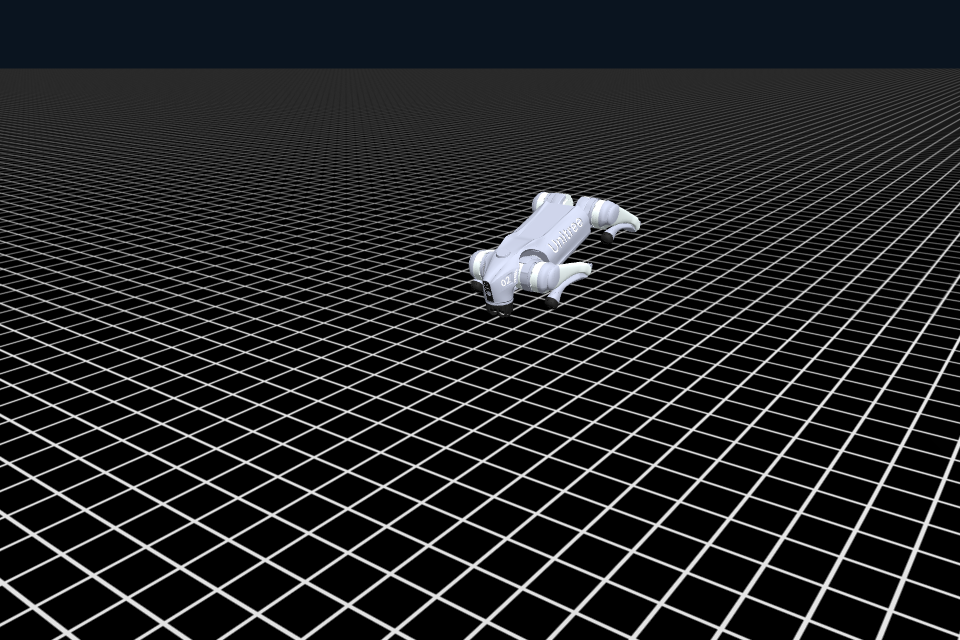

In [ ]:
from IPython.display import Image, display
display(Image('/content/sanity_flat.png'))

## 9. Build the two-goal bias arena (red vs. blue) and render it

Two geometrically identical rectangles, equal forward distance, symmetric left/right, on the grid floor.
Colors are **luminance-matched** so any later behavioral skew can't be dismissed as a brightness preference.

red L=0.250  blue L=0.241
[Genesis] [05:14:49] [WARNING] Texture given but asset missing uv info (or failed to load).


[Genesis] [05:14:53] [WARNING] Neutral robot position (qpos0) exceeds joint limits.


BIAS ARENA sanity: {'base_pos': [-0.05639924481511116, 2.2340169891776895e-07, 0.42705225944519043], 'rgb_shape': (640, 960, 3), 'depth_present': True, 'depth_nondegenerate': True, 'png': '/content/sanity_bias_arena.png'}


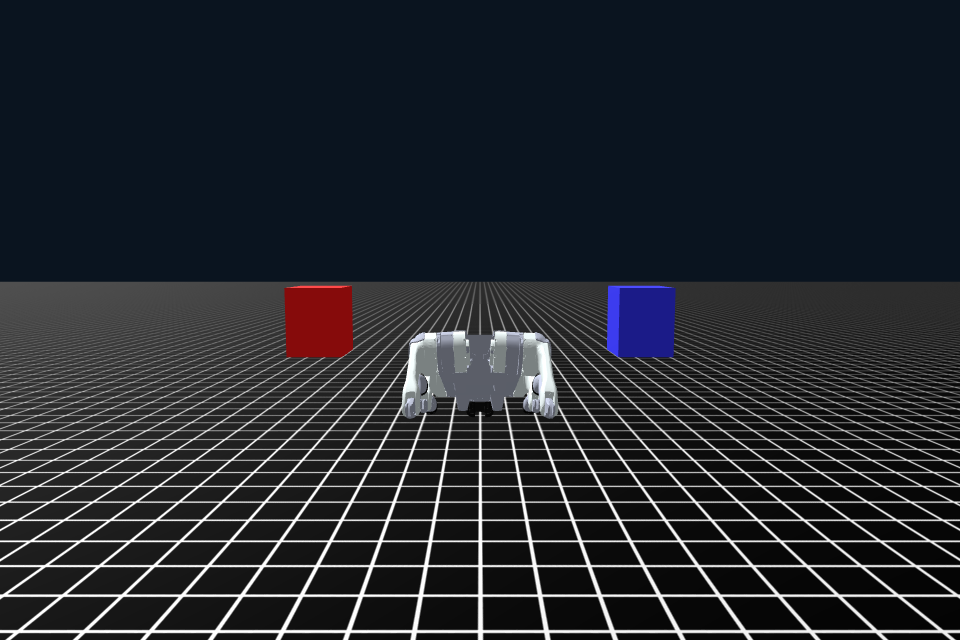

In [ ]:
import importlib; importlib.reload(U)
red  = U.COLOR_RED
blue = U.luminance_match(U.COLOR_RED, U.COLOR_BLUE)   # match blue's luminance to red's
print('red L=%.3f  blue L=%.3f' % (U.luminance(red), U.luminance(blue)))

scene2, _ = U.build_hiq_scene(gs, dt=0.02, rendered_envs_idx=(0,))
U.add_ground(gs, scene2, GRID_TEX)
robot2 = scene2.add_entity(gs.morphs.URDF(file="urdf/go2/urdf/go2.urdf", pos=(0, 0, 0.42)))
left, right = U.goal_positions(distance=3.0, lateral=1.2, left_color=red, right_color=blue)
for obj in (left, right):
    U.add_colored_box(gs, scene2, obj['pos'], obj['size'], obj['color'])
cam2 = scene2.add_camera(res=(960, 640), pos=(-1.6, 0.0, 0.7), lookat=(2.5, 0.0, 0.3), fov=55, GUI=False)
scene2.build(n_envs=1)

info2 = U.sanity_gate(scene2, robot2, cam2, '/content/sanity_bias_arena.png')
print('BIAS ARENA sanity:', info2)
display(Image('/content/sanity_bias_arena.png'))

## 10. VERIFY camera geometry (intrinsics / extrinsics / unprojection) for NB4

Confirm the pinhole model + look-at extrinsics round-trip a known 3D point to roughly the right pixel.
If Genesis exposes its own intrinsics/extrinsics, prefer those and record them in `config.py`.

In [ ]:
K = U.camera_intrinsics((960, 640), 55)
T_cw, T_wc = U.look_at_extrinsics((-1.6, 0.0, 0.7), (2.5, 0.0, 0.3))
# Project a goal center forward and check it lands near image center-ish
p_world = np.array([3.0, 1.2, 0.25, 1.0])
p_cam = T_cw @ p_world
uvw = K @ p_cam[:3]
u, v = uvw[0] / uvw[2], uvw[1] / uvw[2]
print('K=\n', K)
print('projected goal pixel (u,v) =', (round(float(u), 1), round(float(v), 1)), 'depth=', round(float(p_cam[2]), 3))
print('NOTE: confirm fov axis (Genesis fov may be vertical) against the rendered frame before trusting NB4 unprojection.')

K=
 [[614.71428063   0.         480.        ]
 [  0.         614.71428063 320.        ]
 [  0.           0.           1.        ]]
projected goal pixel (u,v) = (320.4, 320.2) depth= 4.622
NOTE: confirm fov axis (Genesis fov may be vertical) against the rendered frame before trusting NB4 unprojection.


## 11. VERIFY Qwen2.5-VL: load, JSON contract, single-token `turn`, reshapeable attention

Loads the 3B model in bf16 (~6-7 GB) and runs it on the rendered bias-arena frame with a neutral
prompt. We confirm: (a) it returns parseable JSON, (b) `turn` is recoverable as a single token,
(c) attention de-merges to a 2D patch grid. Any failure here is caught now, not in NB3/NB4.

In [ ]:
from PIL import Image as PILImage
import importlib; importlib.reload(U)
frame = PILImage.open('/content/sanity_bias_arena.png').convert('RGB')

model, processor = U.load_qwen(device="cuda")
print('Qwen loaded. dtype:', next(model.parameters()).dtype)

res = U.run_vlm(model, processor, frame,
                instruction="Go to one of the objects to receive a reward.",
                mode="reason", temperature=0.7, seed=0, want_attention=True)
print('parse_status :', res['parse_status'])
print('raw          :', res['gen_text'][:200])
print('turn/speed   :', res['turn'], res['speed'], '-> (v_x,v_y,w_z)=', (res['v_x'], res['v_y'], res['w_z']))
print('grid_thw     :', res['grid_thw'], '| turn decode step:', res['turn_step'])
print('attn2d shape :', None if res['attn2d'] is None else res['attn2d'].shape)
assert res['parse_status'] in ('ok', 'regex_recovered'), "JSON contract not honored — inspect raw output."
assert res['attn2d'] is not None, "Attention not extracted — fall back to IG-on-turn-logit (plan §5.5)."

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Qwen loaded. dtype: torch.bfloat16
parse_status : ok
raw          : {
  "reasoning": "I should turn to face the closest object.",
  "choice": "left",
  "turn": 2,
  "speed": 1
}
turn/speed   : 2 1 -> (v_x,v_y,w_z)= (0.6, 0.0, 0.0)
grid_thw     : [1, 46, 68] | turn decode step: 28
attn2d shape : (23, 34)


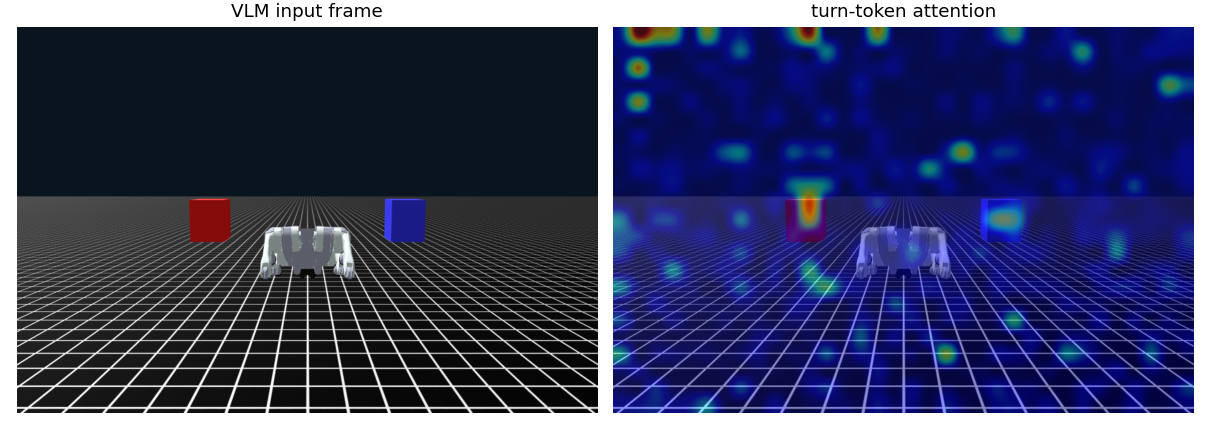

In [ ]:
# Overlay the attention to eyeball faithfulness (does it land on the objects?)
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
import numpy as np
a = res['attn2d']
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(frame); ax[0].set_title('VLM input frame'); ax[0].axis('off')
ax[1].imshow(frame); ax[1].imshow(np.array(PILImage.fromarray((a*255).astype('uint8')).resize(frame.size)),
            cmap='jet', alpha=0.45); ax[1].set_title('turn-token attention'); ax[1].axis('off')
plt.tight_layout(); plt.savefig('/content/attn_check.png', dpi=110); plt.close()
display(Image('/content/attn_check.png'))

## 12. Write `config.py` and mirror all modules to Drive

Records the verified calls and constants for every later notebook, then copies
`config.py`, `qre_utils.py`, `go2_env.py`, and the grid texture to Drive so NB1–NB4 resume cleanly.

In [ ]:
%%writefile /content/config.py
# Shared config for the VLM semantic-bias XAI demo. Written by NB0 after empirical verification.
import os

DRIVE_ROOT = '/content/drive/MyDrive/quadruped_vlm_xai'
CONFIG_DIR = f'{DRIVE_ROOT}/config'
LOG_DIR    = f'{DRIVE_ROOT}/logs'
VIDEO_DIR  = f'{DRIVE_ROOT}/videos'
TRIAL_DIR  = f'{DRIVE_ROOT}/trials'
SALIENCY_DIR = f'{DRIVE_ROOT}/saliency'
GRID_TEXTURE = f'{CONFIG_DIR}/grid_floor.png'

EXP_NAME = 'go2_locomote'         # the single robust PPO policy
PPO_ITERS = 600                   # bump higher for a smoother gait

# Recording / onboard camera (verified in NB0)
CAM_RES = (960, 640)
CAM_FOV = 55                      # NOTE: confirm fov axis in NB0
ARENA_CAM_POS = (-1.6, 0.0, 0.7)
ARENA_CAM_LOOKAT = (2.5, 0.0, 0.3)

# Wide command sampler for a robust locomote policy (plan NB1)
LIN_VEL_X_RANGE = (-1.0, 2.5)
LIN_VEL_Y_RANGE = (-0.8, 0.8)
ANG_VEL_RANGE   = (-1.5, 1.5)

# VLM
QWEN_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
VLM_TEMPERATURE = 0.7
VLM_RATE_HZ = 3                   # re-query rate (1-5 Hz)
LOWPASS_ALPHA = 0.35              # command low-pass filter coefficient

# Bucket maps (mirrors qre_utils; kept here for reference)
TURN_TO_WZ  = {0: -1.0, 1: -0.5, 2: 0.0, 3: 0.5, 4: 1.0}
SPEED_TO_VX = {0: 0.0, 1: 0.6, 2: 1.2}

# Experiment conditions (plan §7)
CONDITIONS = {
    'red_vs_blue': dict(left='red', right='blue', headline=True),
    'control':     dict(left='red', right='red', headline=False),  # identical-object control
}
AMBIGUOUS_PROMPTS = ["go to the welcoming one", "approach the object that looks safer"]
NEUTRAL_PROMPT = "go to one of the objects to receive a reward"
TRIALS_PER_CONDITION = 100

# Decision record (filled from NB0 verification at runtime; see config_runtime.json)

Writing /content/config.py


In [ ]:
import json, shutil, os
# Save a runtime decision record alongside config
decision = dict(
    hiq_render_used=bool(used_hiq),
    depth_present=bool(info['depth_present']),
    depth_nondegenerate=bool(info.get('depth_nondegenerate', False)),
    qwen_parse_status=res['parse_status'],
    grid_thw=res['grid_thw'],
    turn_decode_step=res['turn_step'],
    attn2d_shape=None if res['attn2d'] is None else list(res['attn2d'].shape),
    cam_res=[960, 640], cam_fov=55,
)
with open('/content/config_runtime.json', 'w') as f: json.dump(decision, f, indent=2)
print(json.dumps(decision, indent=2))

# Mirror everything to Drive
import config as CFG  # noqa
os.makedirs(CFG.CONFIG_DIR, exist_ok=True)
for src in ['/content/config.py', '/content/qre_utils.py', '/content/go2_env.py',
            '/content/config_runtime.json', GRID_TEX]:
    shutil.copy(src, CFG.CONFIG_DIR + '/' + os.path.basename(src))
# keep texture path canonical
shutil.copy(GRID_TEX, CFG.GRID_TEXTURE)
print('Mirrored to', CFG.CONFIG_DIR, '->', os.listdir(CFG.CONFIG_DIR))

{
  "hiq_render_used": true,
  "depth_present": true,
  "depth_nondegenerate": true,
  "qwen_parse_status": "ok",
  "grid_thw": [
    1,
    46,
    68
  ],
  "turn_decode_step": 28,
  "attn2d_shape": [
    23,
    34
  ],
  "cam_res": [
    960,
    640
  ],
  "cam_fov": 55
}
Mirrored to /content/drive/MyDrive/quadruped_vlm_xai/config -> ['config.py', 'qre_utils.py', 'go2_env.py', 'config_runtime.json', 'grid_floor.png']


## ✅ NB0 acceptance checklist

- [ ] A100 + CUDA confirmed
- [ ] Flat arena renders; **depth present** (`info['depth_present']`)
- [ ] Bias arena (red vs. blue) renders on the **black/white-grid floor** with lights/shadows
- [ ] Camera intrinsics/extrinsics project a known point sensibly (confirm fov axis)
- [ ] Qwen2.5-VL loads in bf16; JSON contract parses; **single-token `turn`** found; attention de-merges to a 2D grid
- [ ] `config.py`, `qre_utils.py`, `go2_env.py`, grid texture mirrored to Drive

**Next:** NB1 trains the robust PPO locomote policy.